# Propagation diagnostics – three complementary views

1. **Scatter** – which (a, r) match the target frequency, and in which mode type  
2. **Heatmap** – continuous view of which mode region the target falls in (in $R_g$ and in units of $r_{\rm ISCO}$)  
3. **Overlaid propagation diagram** – boundary curves for several spin values on one panel
4. **Mode boundary curves** – p / g / c boundary curves for several (m, n) pairs on three side-by-side panels

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

from setup import *

# ── grid (higher resolution in a for smoother scatter/heatmap) ─────────
params = {
    "m":    (0, 2, 3),
    "j":    (0, 2, 3),       # n = 0, 1, 2
    "a":    (-0.998, 0.998, 120),
    "rivr": (1, 500, 400)
}
pv, ma = create_param_grid(params)
m_g, j_g, A, RIVR = ma
RIVR = np.maximum(RIVR, r_isco(A))

Om  = nu_phi(RIVR, A)       # Ω_φ
Op  = nu_theta(RIVR, A)     # Ω_θ
Kp  = nu_r(RIVR, A)         # κ

NM, NJ, NA, NR = m_g.shape
a_vec = A[0, 0, :, 0]       # 1-D spin vector
r_vec = RIVR[0, 0, 0, :]    # 1-D radius vector (at a fixed a; used only for ref)

# colour / marker coding for mode types
MODE_STYLE = {
    'g': dict(color='steelblue',    marker='o', label='g-mode'),
    'c': dict(color='brown', marker='s', label='c-mode'),
    'p': dict(color='darkorange',   marker='^', label='p-mode'),
}

# spin values used for the overlaid propagation diagram (view 3)
SPIN_OVERLAY = [-0.99, -0.5, 0.0, 0.5, 0.99]
SPIN_COLORS  = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

print(f"Grid shape: {m_g.shape}  (m, n, a, r)")

Grid shape: (3, 3, 120, 400)  (m, n, a, r)


In [33]:
def mode_regions(im, ij, tol_frac=0):
    """
    Return boolean arrays (NA, NR) for g, c, p regions.
    'Match' means: target frequency falls inside the region.
    tol_frac: fractional half-width around NU0 treated as a match band.
    """
    mm = int(round(m_g[im, ij, 0, 0]))
    nn = int(round(j_g[im, ij, 0, 0]))

    lo, hi = NU0 * (1 - tol_frac), NU0 * (1 + tol_frac)

    mO  = mm * Om[im, ij, :, :]          # (NA, NR)
    fpk = mO + Kp[im, ij, :, :]
    fpn = mO + Op[im, ij, :, :] * np.sqrt(nn)
    if mm > 0:
        fmk = mO - Kp[im, ij, :, :]
        fmn = mO - Op[im, ij, :, :] * np.sqrt(nn)
    else:
        fmk = fpk
        fmn = fpn

    if nn == 0:
        if mm == 0:
            kappa_1d = Kp[im, ij, :, :]
            kappa_max = np.nanmax(kappa_1d, axis=-1, keepdims=True)
            r_max_idx = np.nanargmax(kappa_1d, axis=-1)
            ia_idx = np.arange(kappa_1d.shape[0])
            r_max = RIVR[im, ij, ia_idx, r_max_idx]
            r_max = r_max[:, None]
            R_grid = RIVR[im, ij, :, :]
            p = (NU0 <= kappa_max) & (NU0 >= kappa_1d) & ~np.isnan(fpk) & (R_grid < r_max)
        else:
            p = (NU0 <= fmk) & ~np.isnan(fpk)
        c = np.zeros_like(p, dtype=bool)
        g = np.zeros_like(p, dtype=bool)

    elif mm == 0:
        kappa_2d = Kp[im, ij, :, :]
        g = (NU0 <= kappa_2d) & ~np.isnan(kappa_2d)
        c = np.zeros((NA, NR), dtype=bool)
        p = np.zeros((NA, NR), dtype=bool)

    else:
        g = (NU0 >= fmk) & (NU0 <= fpk) & ~np.isnan(fmk) & ~np.isnan(fpk)
        c = (NU0 <= fmn) & (fmn > 0) & ~np.isnan(fmn) & (NU0 > 0)
        p = np.zeros_like(g, dtype=bool)

    # remove g/c overlap with p
    g = g & ~p
    c = c & ~g & ~p

    return g, c, p, mm, nn


def find_continuous_segments(mask):
    segs = []; in_seg = False
    for i, v in enumerate(mask):
        if v and not in_seg:  start = i; in_seg = True
        elif not v and in_seg: segs.append((start, i-1)); in_seg = False
    if in_seg: segs.append((start, len(mask)-1))
    return segs


# ── resonance radius helpers ────────────────────────────────────────────
def r_ivr(a, nu_obs=NU0, m=1, n=1, M=M_BH, n_scan=8000):
    """
    Vertical resonance radius: ω̃ - sqrt(n)·Ω_z = 0
    i.e.  m·Ω_φ(r) - sqrt(n)·Ω_θ(r) = nu_obs
    Sign convention same as ILR/OLR.
    """
    a = float(a)
    isco = float(r_isco(a))
    r = np.geomspace(isco * 1.001, 5000.0, n_scan)

    om_tilde = 2*np.pi*nu_obs - m * 2*np.pi * nu_phi(r, a, M)
    oz       = 2*np.pi * nu_theta(r, a, M)

    # IVR: om_tilde + sqrt(n)*oz = 0
    diff = om_tilde + np.sqrt(n) * oz
    sign_changes = np.where(np.diff(np.sign(diff)) != 0)[0]
    if len(sign_changes) == 0:
        return np.nan
    i = sign_changes[0]
    denom = diff[i+1] - diff[i]
    if denom == 0:
        return float(r[i])
    return float(r[i] - diff[i] * (r[i+1] - r[i]) / denom)


def resonance_curves(a_arr, nu_obs=NU0, m=1, n=1, M=M_BH):
    """Vectorised: return (r_ILR, r_OLR, r_IVR) arrays over a_arr."""
    r_ilr_arr = np.array([r_ilr(a, nu_obs, m, M) for a in a_arr])
    r_olr_arr = np.array([r_olr(a, nu_obs, m, M) for a in a_arr])
    r_ivr_arr = np.array([r_ivr(a, nu_obs, m, n, M) for a in a_arr])
    return r_ilr_arr, r_olr_arr, r_ivr_arr

---
## Heatmap 1 – mode type in $(a, r)$ space  [units: $R_g$]

<>:13: SyntaxWarning: invalid escape sequence '\,'
<>:13: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_6724/1765306793.py:13: SyntaxWarning: invalid escape sequence '\,'
  fr"Mode region of $\nu_0$ in $(a,\,r)$ — target $\nu_0 = {NU0:.2e}$ Hz",
/tmp/ipykernel_6724/1765306793.py:68: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  p_none = mpatches.Patch(color='#F5F5F0', edgecolor='#999', label='no match')
/tmp/ipykernel_6724/1765306793.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.995])


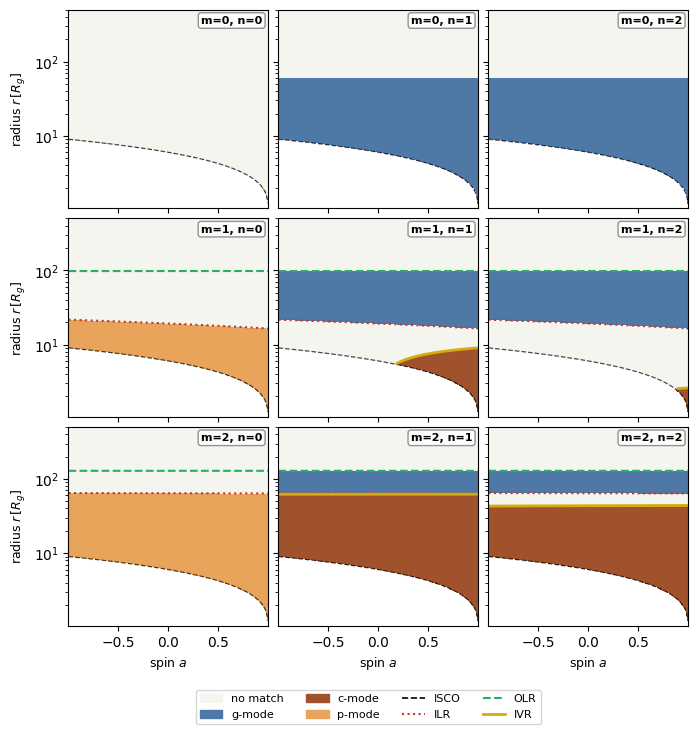

In [41]:
# encode mode type as integer: 0=none, 1=g, 2=c, 3=p
CMAP_DISCRETE = mcolors.ListedColormap(['#F5F5F0', '#4E79A7', '#A0522D', '#E8A45A'])
BOUNDS = [-0.5, 0.5, 1.5, 2.5, 3.5]
NORM   = mcolors.BoundaryNorm(BOUNDS, CMAP_DISCRETE.N)

# coarser spin grid for resonance root-finding (one set per panel)
a_res = np.linspace(-0.998, 0.998, 60)

fig, axes = plt.subplots(NM, NJ, figsize=(8, 8), sharex=True, sharey=True,
                        gridspec_kw={"wspace": 0.05, "hspace": 0.05})
"""
fig.suptitle(
    fr"Mode region of $\nu_0$ in $(a,\,r)$ — target $\nu_0 = {NU0:.2e}$ Hz",
    fontsize=13, y=0.995
)
"""

for im in range(NM):
    for ij in range(NJ):
        ax = axes[im, ij]
        g, c, p, mm, nn = mode_regions(im, ij)

        code = np.zeros((NA, NR), dtype=float)
        code[g] = 1
        code[c] = 2
        code[p] = 3

        R_grid    = RIVR[im, ij, :, :]
        A_grid    = A[im, ij, :, :]
        isco_grid = r_isco(A_grid)
        code[R_grid < isco_grid] = np.nan

        ax.pcolormesh(
            A_grid, R_grid, code,
            cmap=CMAP_DISCRETE, norm=NORM,
            shading='auto', rasterized=True
        )

        # ISCO line
        ax.plot(a_vec, r_isco(a_vec), 'k--', lw=0.9, alpha=0.7)

        # resonance curves — computed for this panel's (mm, nn)
        # ILR/OLR depend on m; IVR depends on m and n
        # skip degenerate m=0 case (no meaningful Lindblad resonances)
        if mm > 0:
            ilr_c, olr_c, ivr_c = resonance_curves(a_res, m=mm, n=max(nn, 1))
            ax.plot(a_res, ilr_c, color='#C0392B', lw=1.5, ls=':')
            ax.plot(a_res, olr_c, color='#27AE60', lw=1.5, ls='--')
            if nn > 0:
                ax.plot(a_res, ivr_c, color='#D4AC0D', lw=2.0, ls='-')

        ax.set_yscale('log')
        ax.set_xlim(-1, 1)
        ax.grid(False)
        ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=4, prune='both'))

        ax.text(0.97, 0.97, f"m={mm}, n={nn}",
                transform=ax.transAxes, fontsize=8, fontweight='bold',
                ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='gray', alpha=0.85))

        if im == NM-1: ax.set_xlabel(r"spin $a$", fontsize=9)
        else:          ax.tick_params(labelbottom=False)
        if ij == 0:    ax.set_ylabel(r"radius $r\,[R_g]$", fontsize=9)
        else:          ax.tick_params(labelleft=False)

# shared legend
p_none = mpatches.Patch(color='#F5F5F0', edgecolor='#999', label='no match')
p_g    = mpatches.Patch(color='#4E79A7', label='g-mode')
p_c    = mpatches.Patch(color='#A0522D', label='c-mode')
p_p    = mpatches.Patch(color='#E8A45A', label='p-mode')
h_i    = mlines.Line2D([],[],color='black',   ls='--', lw=1.2, label='ISCO')
h_ilr  = mlines.Line2D([],[],color='#C0392B', ls=':',  lw=1.5, label='ILR')
h_olr  = mlines.Line2D([],[],color='#27AE60', ls='--', lw=1.5, label='OLR')
h_ivr  = mlines.Line2D([],[],color='#D4AC0D', ls='-',  lw=2.0, label='IVR')
fig.legend(handles=[p_none, p_g, p_c, p_p, h_i, h_ilr, h_olr, h_ivr],
           loc='lower center', ncol=4, fontsize=8, frameon=True,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.05, 1, 0.995])
plt.savefig('cmodes_plots/heatmap_rg.pdf', bbox_inches='tight')
plt.show()

---
## Heatmap 2 – same as above but radius in units of $r_{\rm ISCO}(a)$

<>:8: SyntaxWarning: invalid escape sequence '\,'
<>:8: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_6724/4055938087.py:8: SyntaxWarning: invalid escape sequence '\,'
  fr"Mode region of $\nu_0$ in $(a,\,r/r_{{\rm ISCO}})$ — target $\nu_0 = {NU0:.2e}$ Hz",
/tmp/ipykernel_6724/4055938087.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.995])


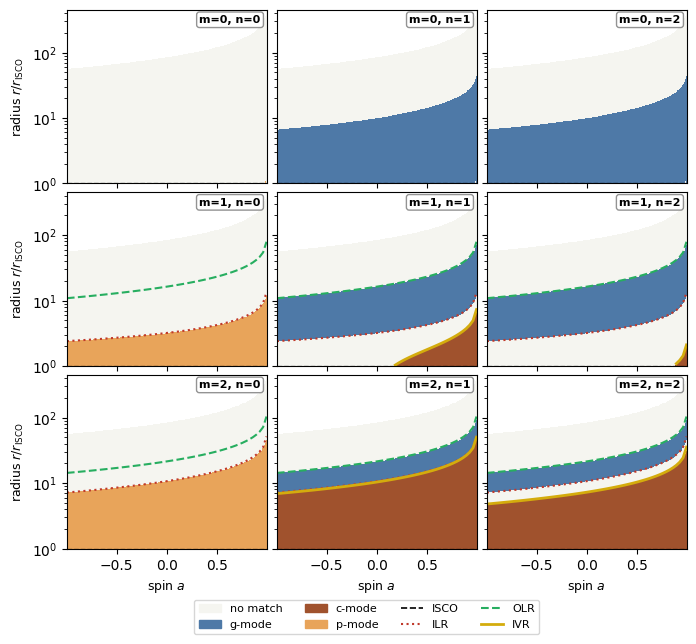

In [ ]:
# Build a uniform grid in r/r_isco for display
# For each (a) we re-normalise R_grid on the fly at plot time

fig, axes = plt.subplots(NM, NJ, figsize=(8, 7), sharex=True, sharey=True,
                             gridspec_kw={"wspace": 0.05, "hspace": 0.05})
"""
fig.suptitle(
    fr"Mode region of $\nu_0$ in $(a,\,r/r_{{\rm ISCO}})$ — target $\nu_0 = {NU0:.2e}$ Hz",
    fontsize=13, y=0.995
)
"""
isco_res = r_isco(a_res)   # denominator for normalisation

for im in range(NM):
    for ij in range(NJ):
        ax = axes[im, ij]
        g, c, p, mm, nn = mode_regions(im, ij)

        code = np.zeros((NA, NR), dtype=float)
        code[g] = 1
        code[c] = 2
        code[p] = 3

        R_grid    = RIVR[im, ij, :, :]          # (NA, NR) in Rg
        A_grid    = A[im, ij, :, :]              # (NA, NR)
        isco_grid = r_isco(A_grid)               # (NA, NR)
        R_norm    = R_grid / isco_grid           # dimensionless

        code[R_grid < isco_grid] = np.nan

        ax.pcolormesh(
            A_grid, R_norm, code,
            cmap=CMAP_DISCRETE, norm=NORM,
            shading='auto', rasterized=True
        )

        # ISCO line at r/r_isco = 1
        ax.axhline(1.0, color='black', ls='--', lw=0.9, alpha=0.7)

        # resonance curves — computed for this panel's (mm, nn), normalised
        if mm > 0:
            ilr_c, olr_c, ivr_c = resonance_curves(a_res, m=mm, n=max(nn, 1))
            ax.plot(a_res, ilr_c / isco_res, color='#C0392B', lw=1.5, ls=':')
            ax.plot(a_res, olr_c / isco_res, color='#27AE60', lw=1.5, ls='--')
            if nn > 0:
                ax.plot(a_res, ivr_c / isco_res, color='#D4AC0D', lw=2.0, ls='-')

        ax.set_yscale('log')
        ax.set_xlim(-1, 1)
        ax.set_ylim(bottom=1.0)
        ax.grid(False)

        ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=4, prune='both'))

        ax.text(0.97, 0.97, f"m={mm}, n={nn}",
                transform=ax.transAxes, fontsize=8, fontweight='bold',
                ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='gray', alpha=0.85))

        if im == NM-1: ax.set_xlabel(r"spin $a$", fontsize=9)
        else:          ax.tick_params(labelbottom=False)
        if ij == 0:    ax.set_ylabel(r"radius $r / r_{\rm ISCO}$", fontsize=9)
        else:          ax.tick_params(labelleft=False)

# shared legend (reuse handles from heatmap 1)
fig.legend(handles=[p_none, p_g, p_c, p_p, h_i, h_ilr, h_olr, h_ivr],
           loc='lower center', ncol=4, fontsize=8, frameon=True,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.05, 1, 0.995])
plt.savefig('cmodes_plots/heatmap_risco.pdf', bbox_inches='tight')
plt.show()

---
## Mode boundary curves — p / g / c on three side-by-side panels

Each panel shows the boundary curves (in the $a$–$r$ plane) for several $(m, n)$ pairs.

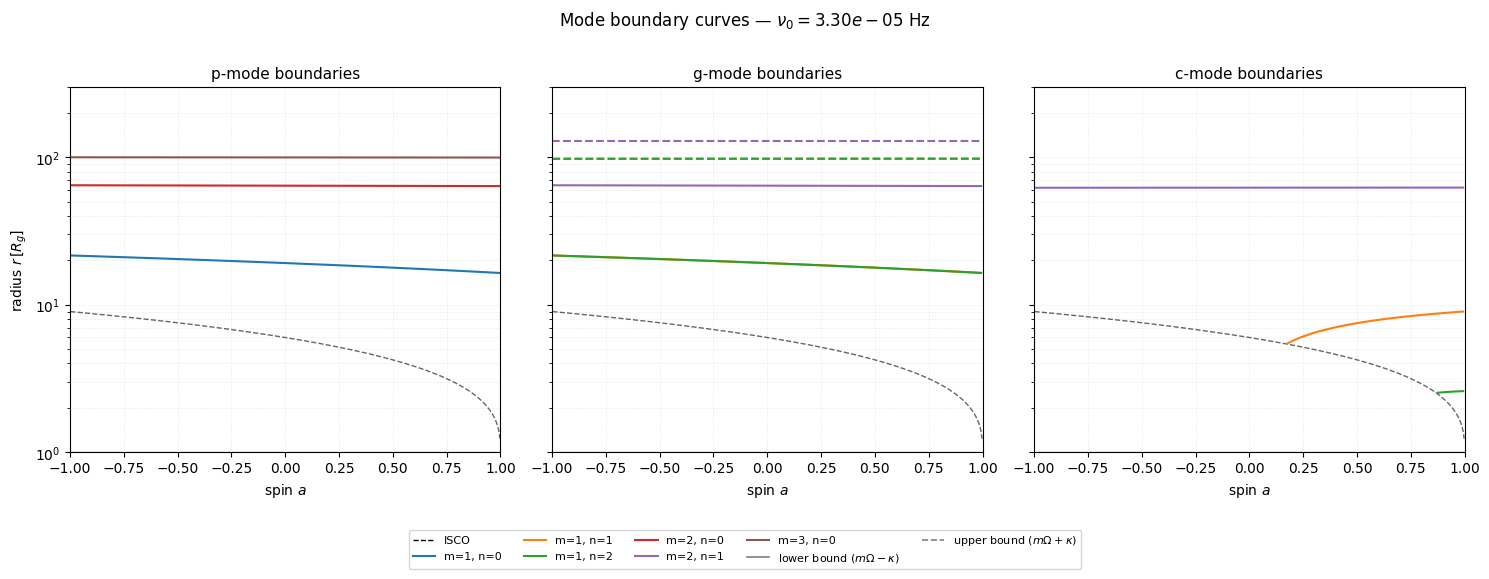

In [ ]:
# (m, n) pairs to draw for each mode type
MN_PAIRS = [
    (1, 0), (1, 1), (1, 2),
    (2, 0), (2, 1),
    (3, 0),
]
PAIR_COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']

# fine 1-D grids for boundary tracing
a_fine = np.linspace(-0.998, 0.998, 300)
r_fine = np.logspace(np.log10(1.01), np.log10(500), 800)
A2, R2 = np.meshgrid(a_fine, r_fine, indexing='ij')   # (NA_fine, NR_fine)

Om2 = nu_phi(R2, A2)
Op2 = nu_theta(R2, A2)
Kp2 = nu_r(R2, A2)
ISCO2 = r_isco(A2)

def boundary_curves_for_mn(mm, nn):
    """
    For a given (m,n) return dicts of boundary arrays suitable
    for contour plotting: keys 'g_lo', 'g_hi', 'c_lo', 'p_lo' etc.
    Returns F2D arrays (NA_fine, NR_fine).
    """
    mO  = mm * Om2
    if mm > 0:
        fmk = mO - Kp2
        fpk = mO + Kp2
        fmn = mO - Op2 * np.sqrt(max(nn, 0))
    else:
        fmk = fpk = mO + Kp2   # degenerate
        fmn = mO + Op2 * np.sqrt(max(nn, 0))

    # mask below ISCO
    phy = R2 >= ISCO2
    fmk = np.where(phy, fmk, np.nan)
    fpk = np.where(phy, fpk, np.nan)
    fmn = np.where(phy, fmn, np.nan)

    return fmk, fpk, fmn


fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
titles = ['p-mode boundaries', 'g-mode boundaries', 'c-mode boundaries']
for ax, ttl in zip(axes, titles):
    ax.set_title(ttl, fontsize=11)
    ax.set_xlabel(r"spin $a$", fontsize=10)
    ax.set_yscale('log')
    ax.set_xlim(-1, 1)
    ax.set_ylim(1, 300)
    # ISCO
    ax.plot(a_fine, r_isco(a_fine), 'k--', lw=1.0, alpha=0.6, label='ISCO')
    ax.axhline(1, color='k', lw=0.3, alpha=0.3)
    ax.grid(True, which='both', ls=':', lw=0.4, alpha=0.5)

axes[0].set_ylabel(r"radius $r\,[R_g]$", fontsize=10)

legend_handles = [mlines.Line2D([],[],color='k',ls='--',lw=1.0,label='ISCO')]

for (mm, nn), col in zip(MN_PAIRS, PAIR_COLORS):
    fmk, fpk, fmn = boundary_curves_for_mn(mm, nn)
    lbl = f"m={mm}, n={nn}"

    # p-mode panel: upper boundary of p region = fmk = NU0 (i.e. mΩ−κ=ν0)
    if mm > 0 and nn == 0:
        # p-mode: ν0 <= m*Ω - κ  →  boundary: m*Ω - κ = ν0
        axes[0].contour(A2, R2, fmk, levels=[NU0], colors=[col], linewidths=1.5)
    elif mm == 0 and nn == 0:
        # κ-mode: κ = ν0
        axes[0].contour(A2, R2, Kp2, levels=[NU0], colors=[col], linewidths=1.5)

    # g-mode panel: two boundaries mΩ−κ and mΩ+κ
    if mm > 0 and nn > 0:
        cs_lo = axes[1].contour(A2, R2, fmk, levels=[NU0], colors=[col],
                                linewidths=1.5, linestyles='-')
        cs_hi = axes[1].contour(A2, R2, fpk, levels=[NU0], colors=[col],
                                linewidths=1.5, linestyles='--')

    # c-mode panel: boundary mΩ − sqrt(n)·Ω_θ = ν0
    if mm > 0 and nn > 0:
        axes[2].contour(A2, R2, fmn, levels=[NU0], colors=[col], linewidths=1.5)

    legend_handles.append(
        mlines.Line2D([],[],color=col, lw=1.5, label=lbl)
    )

# g-mode style note
legend_handles += [
    mlines.Line2D([],[],color='gray', ls='-',  lw=1.2, label='lower bound ($m\\Omega-\\kappa$)'),
    mlines.Line2D([],[],color='gray', ls='--', lw=1.2, label='upper bound ($m\\Omega+\\kappa$)'),
]

fig.legend(handles=legend_handles, loc='lower center', ncol=5,
           fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.12))
fig.suptitle(fr"Mode boundary curves — $\nu_0 = {NU0:.2e}$ Hz", fontsize=12, y=1.01)

plt.tight_layout()
plt.savefig('cmodes_plots/mode_boundaries.pdf', bbox_inches='tight')
plt.show()